In [1]:
import pandas as pd
import pandana as pdna
from pandana.loaders import osm
import numpy as np
import warnings
import matplotlib.pyplot as plt
from pathlib import Path
import geopandas as gpd
import osmnx as ox
import os
import timeit

ox.settings.use_cache = True

ox.settings.log_console = True

In [2]:
start = timeit.timeit() #timing
#osmnx
filepath = "./data/aarhus_network.graphml"
bbox = 9.48446, 56.15291, 9.62522, 56.20804
if(os.path.exists(filepath)):
    G = ox.io.load_graphml(filepath)
else:
    #G = ox.graph.graph_from_bbox(bbox, simplify = True)  
    G = ox.graph.graph_from_place("Aarhus Municipality, Denmark")
    ox.io.save_graphml(G, filepath)

G = ox.project_graph(G)

#pandana
filepath_pan = "./data/aarhus_features.h5"

if(os.path.exists(filepath_pan)):
    n, e = ox.graph_to_gdfs(G)
    e = e.reset_index()
    network = pdna.Network.from_hdf5(filepath_pan)
else:
    n, e = ox.graph_to_gdfs(G)
    e = e.reset_index()
    network = pdna.Network(n.geometry.x, n.geometry.y, e["u"], e["v"], e[["length"]])
    
    network.save_hdf5(filepath_pan)


In [3]:

tags = {"amenity": ["school", "pharmacy","school"], "shop": ["convenience", "supermarket"]}
places = "Aarhus Municipality, Denmark"
#init tags
pois_arr = []
def tags_init(tags, places, pois_arr):
    counter = 0
    for x, y in tags.items():
        print(x , y)
        for itemz in y:
            pois_arr.append (ox.features_from_place(
                places,
                tags={x : itemz}
            ).to_crs(n.crs))
            pois_arr[counter]["geometry"] = pois_arr[counter].geometry.centroid
            counter += 1
tags_init(tags,places,pois_arr)

amenity ['school', 'pharmacy', 'school']
shop ['convenience', 'supermarket']


Basically, you feed it a dictionary of tags, and a place. then i will pull the features from that place using the tag list.
the print just tells you what catagories and tags are pulled. (mostly for debugging)

In [4]:
distance = 20000
dist = 500
maxitems = 1000
n["pois"] = 0
tagsc = []

for cat, tags_list in tags.items():
        for items in tags_list:
            tagsc.append(items)
print(tagsc)    
counta = 0
for items in pois_arr:
    network.set_pois(
                category= tagsc[counta],
                maxdist=distance,
                maxitems=maxitems,
                x_col=items.geometry.x,
                y_col=items.geometry.y,
                )
    nearest_pois = network.nearest_pois(
                distance=distance,
                category=tagsc[counta],
                num_pois=1,
                )
    counta += 1
    n["pois"] = n["pois"] + (nearest_pois <= dist).sum(axis=1)



['school', 'pharmacy', 'school', 'convenience', 'supermarket']


This cell unpacks all the tags, then uses them to preform point of interest search per tag.
This is then mashed up in a "atleast 1 " poi layer graph with all tags.


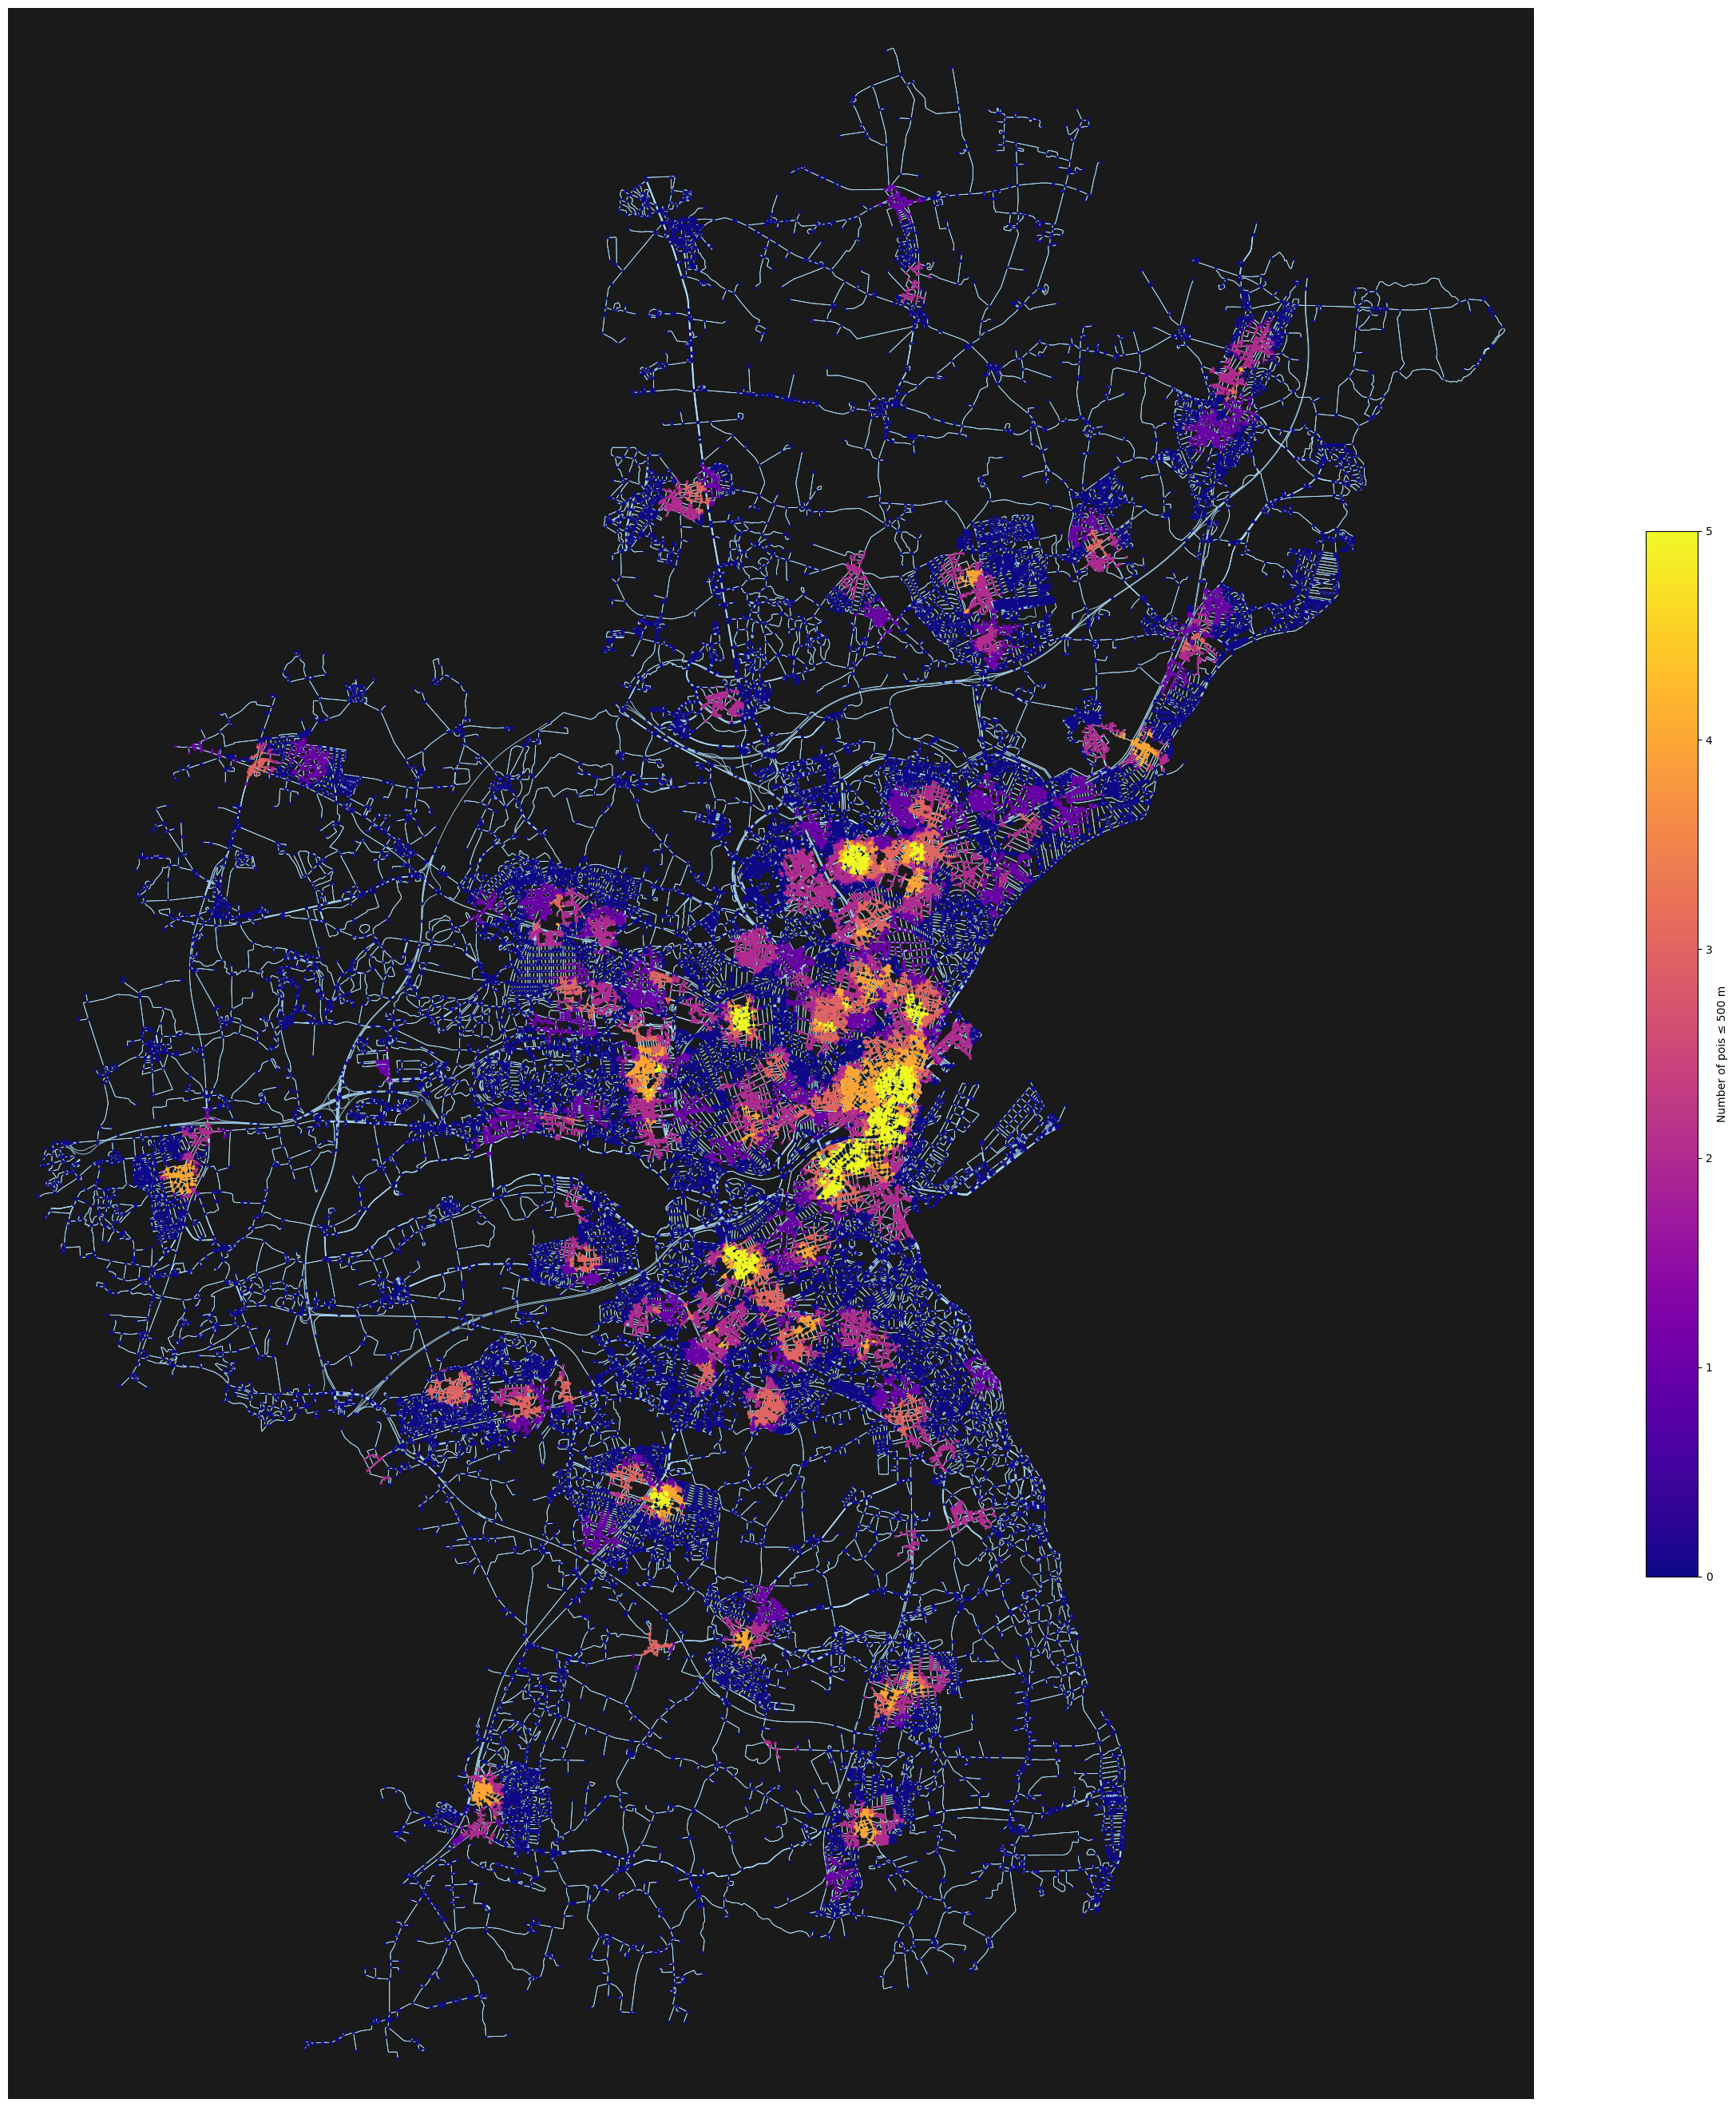

In [5]:
fig, ax = ox.plot.plot_graph(
    G,
    node_size=0,
    edge_color="#afdffe",
    edge_linewidth=0.6,
    bgcolor="#1a1a1a",
    show=False,
    close=False,
    figsize=(36,34)
)

vmin = n["pois"].min()
vmax = n["pois"].max()

n.plot(
    ax=ax,
    column="pois",
    cmap="plasma",
    markersize=3.5,
    alpha=0.8,
    legend=True,
    legend_kwds={
        "shrink": 0.5,
        "label": f"Number of pois ≤ {dist} m",
        "orientation": "vertical"
    },
    vmin=0,
    vmax=vmax
)

plt.show()

While it has already been mentioned, this is a 5 layer graph(at the time of writing), as every tag is a layer. whereas the previous mashup
simply layered pois_a, pois_b and pois_c. with each as a layer.